# Section 1: Han2Han (PyTorch, 169M)

Load the Han2Han PyTorch checkpoint, extract three-condition document embeddings (Original->Original, Original->Hangul, Hangul->Hangul), and visualize in 2D + 3D.


## Setup

In [16]:
#!/usr/bin/env python3
# coding: utf-8

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE = torch.bfloat16 if DEVICE == 'cuda' else torch.float32

from transformers import AutoTokenizer
from modeling_han2han_pytorch import Han2Han, Han2HanConfig

print(f'device={DEVICE} dtype={DTYPE}')

2026-05-26 18:15:25,877 - INFO - jax._src.xla_bridge - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-05-26 18:15:25,877 - WARNING - jax._src.xla_bridge - An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.
2026-05-26 18:15:25,878 - INFO - han2han_tokenizer - Han2Han tokenizer registered with HuggingFace AutoClasses!
Han2Han models and tokenizer registered with HuggingFace AutoClasses!
device=cuda dtype=torch.bfloat16


## Load checkpoint

In [17]:
han2han_ckpt = 'han2han-ul2-base-1-it-pytorch/latest_step_43153'

config = Han2HanConfig.from_pretrained(han2han_ckpt)
tokenizer = AutoTokenizer.from_pretrained('han2han_v2_tokenizer')

print(f"Config: {config.d_model}d, {config.encoder_nlayer}L")
print(f"Tokenizer vocab size: {len(tokenizer)}")

2026-05-26 18:15:27,100 - INFO - han2han_tokenizer - Detected 1024 sentinel tokens starting at ID 17
2026-05-26 18:15:27,100 - INFO - han2han_tokenizer - Detected byte fallback tokens starting at ID 1041
Config: 640d, 18L
Tokenizer vocab size: 38400


In [18]:
model = Han2Han.from_pretrained(han2han_ckpt, torch_dtype=DTYPE)
model.to(DEVICE).eval()

print(f'params={sum(p.numel() for p in model.parameters())/1e6:.1f}M')


Loading weights:   0%|          | 0/821 [00:00<?, ?it/s]

params=169.2M


## Load data

In [19]:
import polars as pl 

df = pl.read_ipc('casasia_umap.arrow')
df

sentences,year
list[str],i32
"[""美術展覽 計劃."", ""總督府 事案으로 明年 初次 開設總督府에서는 朝鮮에 在한 美術의 發達을 裨補할 목적으로 東京의 帝國美術院展覽會를 倣하여 每年 一次 美術展覽會를 開할 方針을 內定하고 時 二十六日 午前 十時 總督府 第二會議室에 朴泳孝 侯, 閔丙奭 子, 書畵協會의 丁大有, 金敦熙, 李道榮 外 諸氏, 書畵硏究會의 金圭鎭 氏, 日本人側 書畵家로 高木背水 外 數氏 其他 書畵家에 關係있는 人士를 招請하고 水野 政務總監 以下 學務當局者가 會合하여 此에 關한 相議會를 開한바 滿場一致로 此計劃에 對한 贊成이 有하였으므로 此에 關한 規定의 發表가 有하리라는데 該展覽會는 此를 東洋畵(第一部), 西洋畵 及 彫刻(第二部), 書(第三部)의 三部로 定하고 出品人의 資格은 制限치 아니하되 出品은 審査委員의 鑑査를 經한 것에 限하여 陳列하며 特別히 前回의 展覽會에서 一等賞을 受한 者와 其他 特別한 者에는 無鑑査出品을 認定하여 同一人의 出品은 各部에 二點 以內로 出品."", ""一點은 幅二間 以內로 制限하였으며 出品은 製作本人이 반드시 此를 □하되 故人의 製作은 相續人이 出品함을 得하며 (一) 製作 後 五年을 經過한 것 (二) 該展覽會에 陳列하였던 것 (三) 治安風敎에 有害하다고 認한 것은 出品치 못하며 出品코자 하는 者는 作品을 相當히 表裝하고 每點에 命題 及 出品人 氏名을 記한 出品札을 添附하여 出品願書 解說書와 共히 事務所에 提出함을 要하며 作品의 鑑査 及 審査를 行하기 爲하여 審査委員會를 設하되 委員長은 政務總監이 此에 當하고 委員은 官民을 通하여 學識經驗이 有한 人士로 選하여 一, 二, 三部의 各部에 分屬케 하여 初次에는 出品한 作品의 陳列할 與否를 鑑査하고 更히 鑑査를 行한 陳列品에 對하여 總히 審査를 行하되 各部 委員 過半數의 出席과 出席委員 過半數의 同意로써 此를 定하며 審査의 結果 優秀한 作品에는 一, 二, 三四의 等級을 定하여 入賞한 作品의 製作者에게는 金牌(一等), 銀牌(二等), 銅牌(三等), 褒狀(四等)의 賞品을 朝鮮總督이 授與할 터이며 明年 五, 六月의 交에 京城 永樂町 商品陳列館을 會場으로 使用하여 會期 約 三十日間으로 第一回 展覽會를 開하고 每日 午前 九時부터 午後 五時까지 一般에 公開하기로 方今 計劃 準備中이라더라.""]",1921
"[""美術展覽會 計劃."", ""審査委員 選定에 注意 朝鮮에 美術學校를 設立할 意思가 總督府側에 存在하는 것은 이미 本報에 報道된 바라."", … ""이 意味에 在하여 吾人은 審査委員長에 政務總監이라는 俗人이 依例히 當하게 된 것을 不可하다 하며 斯界의 大家로서 함을 要望하노니 審査委員을 精密히 하지 아니하고 그 어찌 眞正한 藝術의 發達을 期待할 수 있으리오.""]",1921
"[""美展 開設의 趣旨."", ""柴田 學務局長 談現今 朝鮮에서는 美術이 可見할 者이 甚少하나 그러나 此를 往昔 新羅 高麗朝에 回顧하면 朝鮮美術의 發達은 實로 顯著한 者가 有하여 其作品이 今에 遺存하여 後人으로서 驚嘆케 하는 것이 有하도다."", … ""如斯히 하여 朝鮮의 文化向上을 爲하여 微力을 盡함을 得하게 되면 吾等의 誠히 幸甚이라 하는 바이라.""]",1921
"[""朝鮮 美術界에 曙光."", ""情操의 高雅와 思想의 鈍化 朝鮮美術審査委員會 規程第一條 朝鮮美術展覽會의 出品을 審査하기 爲하여 朝鮮總督府에 朝鮮美術審査委員會를 置함.第二條 朝鮮美術審査委員會는 委員長 及 委員 若干人으로서 此를 組織함.第三條 委員長은 政務總監으로서 此에 充함."", … ""昨 二十六日 京城 在住의 重要 內鮮人 畵家 五百家의 參集乞을 하고 總監이 本展覽會의 趣旨를 說하였는데 內地의 所謂 帝展과 異함은 書도 美術로 認한 事이나 明年 五,六月頃에 京城에서 第一會를 開設할 豫定인데 如斯히 하여 朝鮮에 在한 文化向上을 爲하여 聊히 微力을 盡함을 得하면 吾等의 實로 幸甚으로 하는 바이라.""]",1921
"[""展覽 委員 詮衡."", ""委員長은 水野 總督豫히 總督府에서 計劃中이던 朝鮮美術展覽會는 遂히 成立을 見하게 되어 同 展覽會 規程 及 審査委員會 規程이 制定되었으며 來年 五,六月頃에 第一回 展覽을 市內 商品陳列墩에서 開催할 豫定인데 同 展覽會 規程을 見한 즉 第一部 東洋畵, 第二部 西洋畵 及 彫刻, 第三部 書의 三部에 分하고 出品은 自己의 製作한 것에 限하며 同一人의 出品은 各部에 對하여 二點에 內로 하고 委員은 出品物을 選하여 一, 二, 三, 四等에 分하여 所定의 褒賞을 行한다는데 審査委員長은 委員會 規程에 依하여 政務總監이 此에 當하며 委員은 當局에서 目下 詮議 中이라더라.""]",1921
…,…
"[""第卄三回朝鮮美術展覽會開く."", ""(六月四日)半島藝術の最高峰, 第二十三回朝鮮美術展覽會は, 決戰意圖を逞しく盛つて六月四日から總督府美術館で豪壯な蓋をあけた, 出品作品の搬入點數は東洋畵百五點, 西洋畵七百二十三點, 彫刻三十五點, 工藝百七十七點計一千四十點でそのうち入選は東洋畵四十七點, (うち初入選十點) 洋畵八十五點(うち初入選五十九點) 彫刻二十點(うち初入選六點) 工藝百二點(うち初入選二十點) 計三百五十四點(初入選計九十五點)別に無鑑査東洋畵十二點, 洋畵二十五點, 彫刻一點, 工藝四點, 總出品點數三百九十六點と決定, 五月二十九日發表された."", … ""東洋畵 伊東深水氏西洋畵 寺內萬治郞氏彫洋刻 日名子實三氏工洋藝 六角洋多良氏""]",1944
"[""繪と展覽會."", ""遠田運雄(洋畵家) 展覽會では畵家が競技をして自作と他を比較し自己の短を知り, 他の長を採る事が出來る, 鑑賞家側も取り取りの中から自己の好みを見出し繪の優劣を比較したりする事も可能である."", … ""ポスタ―油繪を其對照に置いたのであるが等しく見劣りと言つても全く物にも成らぬ程度の作品が多くて困る.""]",1944
"[""美展會場은 總督府 뒤의 建物."", ""出品申瞬 十一日까지第十回 朝鮮總督府 美展期日도 切迫하여 本月 十一日이 願書 締切인데 昨今 出品 申瞬이 殺到하여서 八日까지의 出品願書 受付數는 東洋畵 三十點, 西洋畵 二三○點, 書 及 四君子 一三○點, 計 三九○點이라는 狀況으로 이를 前回의 締切 三日前에 比하면 大差가 없는 模樣이다."", … ""事務所도 十二日에는 學務局으로부터 此處에 移轉하기로 되었다 한다.""]",1931


In [20]:
# to_len = lambda inp: len(tokenizer(inp)['input_ids'])

# df = pl.read_parquet('casasia_sentences.parquet').select(
#     pl.col('original_text').cast(pl.List(pl.Utf8)).alias('sentences'),
#     pl.col('source').str.to_date(format="%Y").dt.year().sort().alias('year'),
#     pl.col('original_text')
# ).with_columns(
#     pl.col('original_text').map_elements(to_len, return_dtype=pl.Int32).alias('num_toks')
#     ).filter(pl.col('num_toks').is_between(32,512)).drop('num_toks', 'original_text')

# df

## The idea here

We plan on using multiple models, comparing embeddings of:

1. Hanja+Hangul (mixed script, original text) in encoder, original text in decoder
2. Mixed script in encoder, Hangul in decoder
3. Hangul in both encoder/decoder

Because it's only possible for Han2Han to process the second option it might be redundant but still interesting to see if the representations are different or similar.

## Extract embeddings

In [21]:
from h2hcollator import BARTCollator
from tqdm.auto import tqdm

def extract_document_embeddings(df, collator, model, script_token_id):

    model.eval()

    yr_to_embs = {}

    # batch processing
    batch_size = 32  # adjust based on memory
    articles_list = []
    years_list = []

    # collect all data first
    for article, year in df.iter_rows():
        articles_list.append(article)
        years_list.append(year)

    # process in batches
    for i in tqdm(range(0, len(articles_list), batch_size), desc="Processing batches"):
        batch_articles = articles_list[i:i+batch_size]
        batch_years = years_list[i:i+batch_size]

        # prepare batch for collator
        batch_data = [
            {"original_text": " ".join(article),
            "sentences": article,
            "metadata": str(year)}
            for article, year in zip(batch_articles, batch_years)
        ]

        # collate batch (returns numpy arrays)
        inputs = collator(batch_data, cooldown_phase=True)
        inputs.pop("labels")

        input_ids = torch.from_numpy(np.asarray(inputs['input_ids'])).long().to(DEVICE)
        attention_mask = torch.from_numpy(np.asarray(inputs['attention_mask'])).long().to(DEVICE)
        decoder_input_ids = torch.from_numpy(np.asarray(inputs['decoder_input_ids'])).long().to(DEVICE)
        decoder_attention_mask = torch.from_numpy(np.asarray(inputs['decoder_attention_mask'])).long().to(DEVICE)

        with torch.no_grad():
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                decoder_input_ids=decoder_input_ids,
                decoder_attention_mask=decoder_attention_mask,
                use_cache=False,
                return_dict=True,
            )
            # Seq2SeqLMOutput.hidden_states is the decoder's last hidden state, [B, T, D]
            hidden_states = outputs.hidden_states

            # mean-pool decoder states, masking out script-token positions for methodological
            # purity (parity with T5G2 pooling); empirically the mask barely changed the pooled
            # representation -- the script-marker isn't where semantic content lives -- but the
            # clean comparison surface is worth keeping. EOS tokens remain in the pool (matched
            # with T5G2 which also keeps them).
            not_script_mask = (decoder_input_ids != script_token_id).to(decoder_attention_mask.dtype)
            mask = (decoder_attention_mask * not_script_mask).unsqueeze(-1).to(hidden_states.dtype)
            masked_hidden = (hidden_states * mask).sum(dim=1)
            sum_mask = mask.sum(dim=1).clamp(min=1e-9)
            final_embeddings = masked_hidden / sum_mask

        # map back to years
        for year, embedding in zip(batch_years, final_embeddings.float().cpu().numpy()):
            yr_to_embs.setdefault(year, [])
            yr_to_embs[year].append(embedding)

    return yr_to_embs

### 1. Original -> Original

In [22]:
collator = BARTCollator(tokenizer=tokenizer, rng=np.random.default_rng(734),
                        model_max_length=512, max_length=512, hangul_decoder=False,
                        infilling_ratio=0.0, sentence_permutation=False, hangul_only=False,
                        use_morpheme_masking=0.0)

yr_to_embs_o_o = extract_document_embeddings(df, collator, model, tokenizer._hanja_token_id)

2026-05-26 18:15:42,983 - INFO - h2hcollator - MeCab initialized as primary tokenizer


Processing batches:   0%|          | 0/36 [00:00<?, ?it/s]

### 2. Original -> Hangul

In [23]:
collator = BARTCollator(tokenizer=tokenizer, rng=np.random.default_rng(734),
                        model_max_length=512, max_length=512, hangul_decoder=True,
                        infilling_ratio=0.0, sentence_permutation=False, hangul_only=False,
                        use_morpheme_masking=0.0)

yr_to_embs_o_h = extract_document_embeddings(df, collator, model, tokenizer._hangul_token_id)

2026-05-26 18:16:01,525 - INFO - h2hcollator - MeCab initialized as primary tokenizer


Processing batches:   0%|          | 0/36 [00:00<?, ?it/s]

### 3. Hangul -> Hangul

In [24]:
collator = BARTCollator(tokenizer=tokenizer, rng=np.random.default_rng(734),
                        model_max_length=512, max_length=512, hangul_decoder=True,
                        infilling_ratio=0.0, sentence_permutation=False, hangul_only=True,
                        use_morpheme_masking=0.0)

yr_to_embs_h_h = extract_document_embeddings(df, collator, model, tokenizer._hangul_token_id)

2026-05-26 18:16:48,571 - INFO - h2hcollator - MeCab initialized as primary tokenizer


Processing batches:   0%|          | 0/36 [00:00<?, ?it/s]

## UMAP visualization

Reduce all three conditions jointly with UMAP so they share a coordinate system, then plot in 2D and 3D. Light gray lines connect the same document across conditions.

In [25]:
import umap
import matplotlib.pyplot as plt
from itertools import chain

In [26]:
embs_o_o = np.vstack([*chain.from_iterable(yr_to_embs_o_o.values())])
embs_o_h = np.vstack([*chain.from_iterable(yr_to_embs_o_h.values())])
embs_h_h = np.vstack([*chain.from_iterable(yr_to_embs_h_h.values())])

embs_o_o.shape, embs_o_h.shape, embs_h_h.shape

((1124, 640), (1124, 640), (1124, 640))

In [27]:
# stack all embeddings together
all_embs = np.vstack([embs_o_o, embs_o_h, embs_h_h])  # (3372, 768)

### 2D

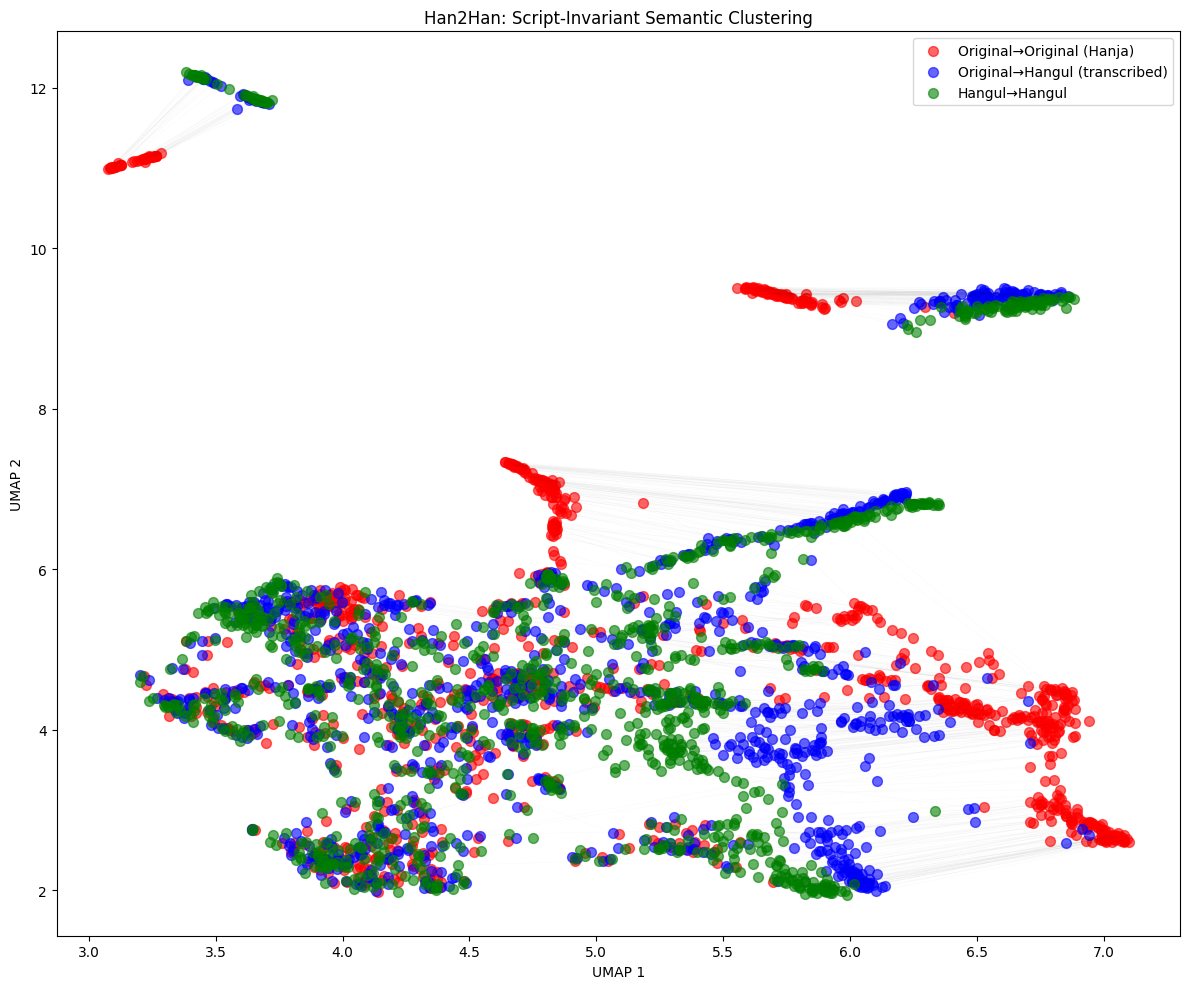

In [33]:
# create labels for each condition
labels = (
    ['Original→Original'] * len(embs_o_o) +
    ['Original→Hangul'] * len(embs_o_h) +
    ['Hangul→Hangul'] * len(embs_h_h)
)

# fit UMAP on all data together (shared embedding space)
reducer = umap.UMAP(
    n_components=2,
    random_state=202,    # chose this from below visualizations
    n_neighbors=30,      # higher = capture more global structure (try 30-100)
    min_dist=0.1,        # lower = tighter clusters (try 0.0-0.1)
    metric='cosine',
    spread=0.5,          # controls embedding spread (try 0.5-2.0)
    init='random'
)

all_2d = reducer.fit_transform(all_embs)

# split back into the three conditions
embs_o_o_2d = all_2d[:len(embs_o_o)]
embs_o_h_2d = all_2d[len(embs_o_o):len(embs_o_o) + len(embs_o_h)]
embs_h_h_2d = all_2d[len(embs_o_o) + len(embs_o_h):]

# plot
plt.figure(figsize=(12, 10))
plt.scatter(embs_o_o_2d[:, 0], embs_o_o_2d[:, 1],
            label='Original→Original (Hanja)', alpha=0.6, s=50, c='red')
plt.scatter(embs_o_h_2d[:, 0], embs_o_h_2d[:, 1],
            label='Original→Hangul (transcribed)', alpha=0.6, s=50, c='blue')
plt.scatter(embs_h_h_2d[:, 0], embs_h_h_2d[:, 1],
            label='Hangul→Hangul', alpha=0.6, s=50, c='green')

# Han2Han plot with connecting lines for same documents
for i in range(len(df)):
    # draw light gray lines connecting the same document across 3 conditions
    points = np.array([embs_o_o_2d[i], embs_o_h_2d[i], embs_h_h_2d[i]])
    plt.plot(points[:, 0], points[:, 1], 'k-', alpha=0.02, linewidth=0.5, zorder=1)

plt.title('Han2Han: Script-Invariant Semantic Clustering')
plt.legend()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()


### 3D

In [32]:
import plotly.graph_objects as go

# fit UMAP on all data together (shared embedding space) - 3D
reducer = umap.UMAP(
    n_components=3,
    random_state=202,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    spread=0.5,
    init='random'
)
all_3d = reducer.fit_transform(all_embs)

# split back into the three conditions
embs_o_o_3d = all_3d[:len(embs_o_o)]
embs_o_h_3d = all_3d[len(embs_o_o):len(embs_o_o) + len(embs_o_h)]
embs_h_h_3d = all_3d[len(embs_o_o) + len(embs_o_h):]

# create plotly figure
fig = go.Figure()

# add scatter points for each condition
fig.add_trace(go.Scatter3d(
    x=embs_o_o_3d[:, 0], y=embs_o_o_3d[:, 1], z=embs_o_o_3d[:, 2],
    mode='markers',
    marker=dict(size=4, color='red', opacity=0.6),
    name='Original→Original (Hanja)'
))
fig.add_trace(go.Scatter3d(
    x=embs_o_h_3d[:, 0], y=embs_o_h_3d[:, 1], z=embs_o_h_3d[:, 2],
    mode='markers',
    marker=dict(size=4, color='blue', opacity=0.6),
    name='Original→Hangul (transcribed)'
))
fig.add_trace(go.Scatter3d(
    x=embs_h_h_3d[:, 0], y=embs_h_h_3d[:, 1], z=embs_h_h_3d[:, 2],
    mode='markers',
    marker=dict(size=4, color='green', opacity=0.6),
    name='Hangul→Hangul'
))

# add connecting lines for same documents
for i in range(len(df)):
    fig.add_trace(go.Scatter3d(
        x=[embs_o_o_3d[i, 0], embs_o_h_3d[i, 0], embs_h_h_3d[i, 0]],
        y=[embs_o_o_3d[i, 1], embs_o_h_3d[i, 1], embs_h_h_3d[i, 1]],
        z=[embs_o_o_3d[i, 2], embs_o_h_3d[i, 2], embs_h_h_3d[i, 2]],
        mode='lines',
        line=dict(color='gray', width=1),
        opacity=0.1,
        showlegend=False
    ))

fig.update_layout(
    title='Han2Han: Script-Invariant Semantic Clustering (3D)',
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='white',
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    width=900,
    height=700
)

fig.show()


## Diagnostics

Parameter count and a multi-seed UMAP grid that was used to pick `random_state=202`. Kept for reproducibility; not used in the paper figures.

In [30]:
def count_parameters(model):
    """Total unique trainable parameters. `model.parameters()` already dedups
    tied params by identity, so a plain sum is correct."""
    return sum(p.numel() for p in model.parameters())


total = count_parameters(model)
print(f"Total unique parameters: {total:,} ({total / 1e6:.2f}M)")


def count_parameters_detailed(model):
    """Per-component parameter count, honoring Han2Han tying flags.

    Han2Han uses separate flags per tying axis:
      tie_encoder_decoder         entire encoder/decoder stack shared
      tie_word_embeddings         encoder.wte tied to decoder.wte
      tie_subtoken_embeddings     encoder.wse/wje tied to decoder.wse/wje
      tie_input_output_embeddings decoder.wte tied to lm_head

    Walks components in order (encoder, decoder, lm_head); each later
    component only gets credit for `nn.Parameter` objects not already counted
    under an earlier one. `state_dict()` is used only for the naive total --
    its keys duplicate tied tensors, which is what produces the 2x reading.
    """
    cfg = model.config
    component_names = [n for n in ('encoder', 'decoder', 'lm_head') if hasattr(model, n)]

    seen_ids = set()
    component_totals = []
    for name in component_names:
        submodule = getattr(model, name)
        size = 0
        for p in submodule.parameters():
            pid = id(p)
            if pid in seen_ids:
                continue
            seen_ids.add(pid)
            size += p.numel()
        component_totals.append((name, size))

    total_unique = sum(s for _, s in component_totals)
    naive = sum(t.numel() for t in model.state_dict().values())

    print("Per-component (deduped against earlier components):")
    for name, size in component_totals:
        label = f"{name} (unique)"
        print(f"  {label:<32} {size:>12,} ({size / 1e6:6.2f}M)")
    print(f"  {'Total unique':<32} {total_unique:>12,} ({total_unique / 1e6:6.2f}M)")

    print()
    print(f"Naive total (state_dict, dups):  {naive:>12,} ({naive / 1e6:.2f}M)")
    if naive > total_unique:
        savings = naive - total_unique
        print(f"Tied-weight savings:             {savings:>12,} ({savings / 1e6:.2f}M)")

    print()
    print("Tying flags:")
    for name in (
        'tie_encoder_decoder',
        'tie_word_embeddings',
        'tie_subtoken_embeddings',
        'tie_input_output_embeddings',
    ):
        print(f"  {name + ':':<32} {getattr(cfg, name, False)}")


count_parameters_detailed(model)


Total unique parameters: 169,203,712 (169.20M)
Per-component (deduped against earlier components):
  encoder (unique)                  129,286,400 (129.29M)
  decoder (unique)                   39,917,312 ( 39.92M)
  lm_head (unique)                            0 (  0.00M)
  Total unique                      169,203,712 (169.20M)

Naive total (state_dict, dups):   338,286,592 (338.29M)
Tied-weight savings:              169,082,880 (169.08M)

Tying flags:
  tie_encoder_decoder:             True
  tie_word_embeddings:             True
  tie_subtoken_embeddings:         False
  tie_input_output_embeddings:     True


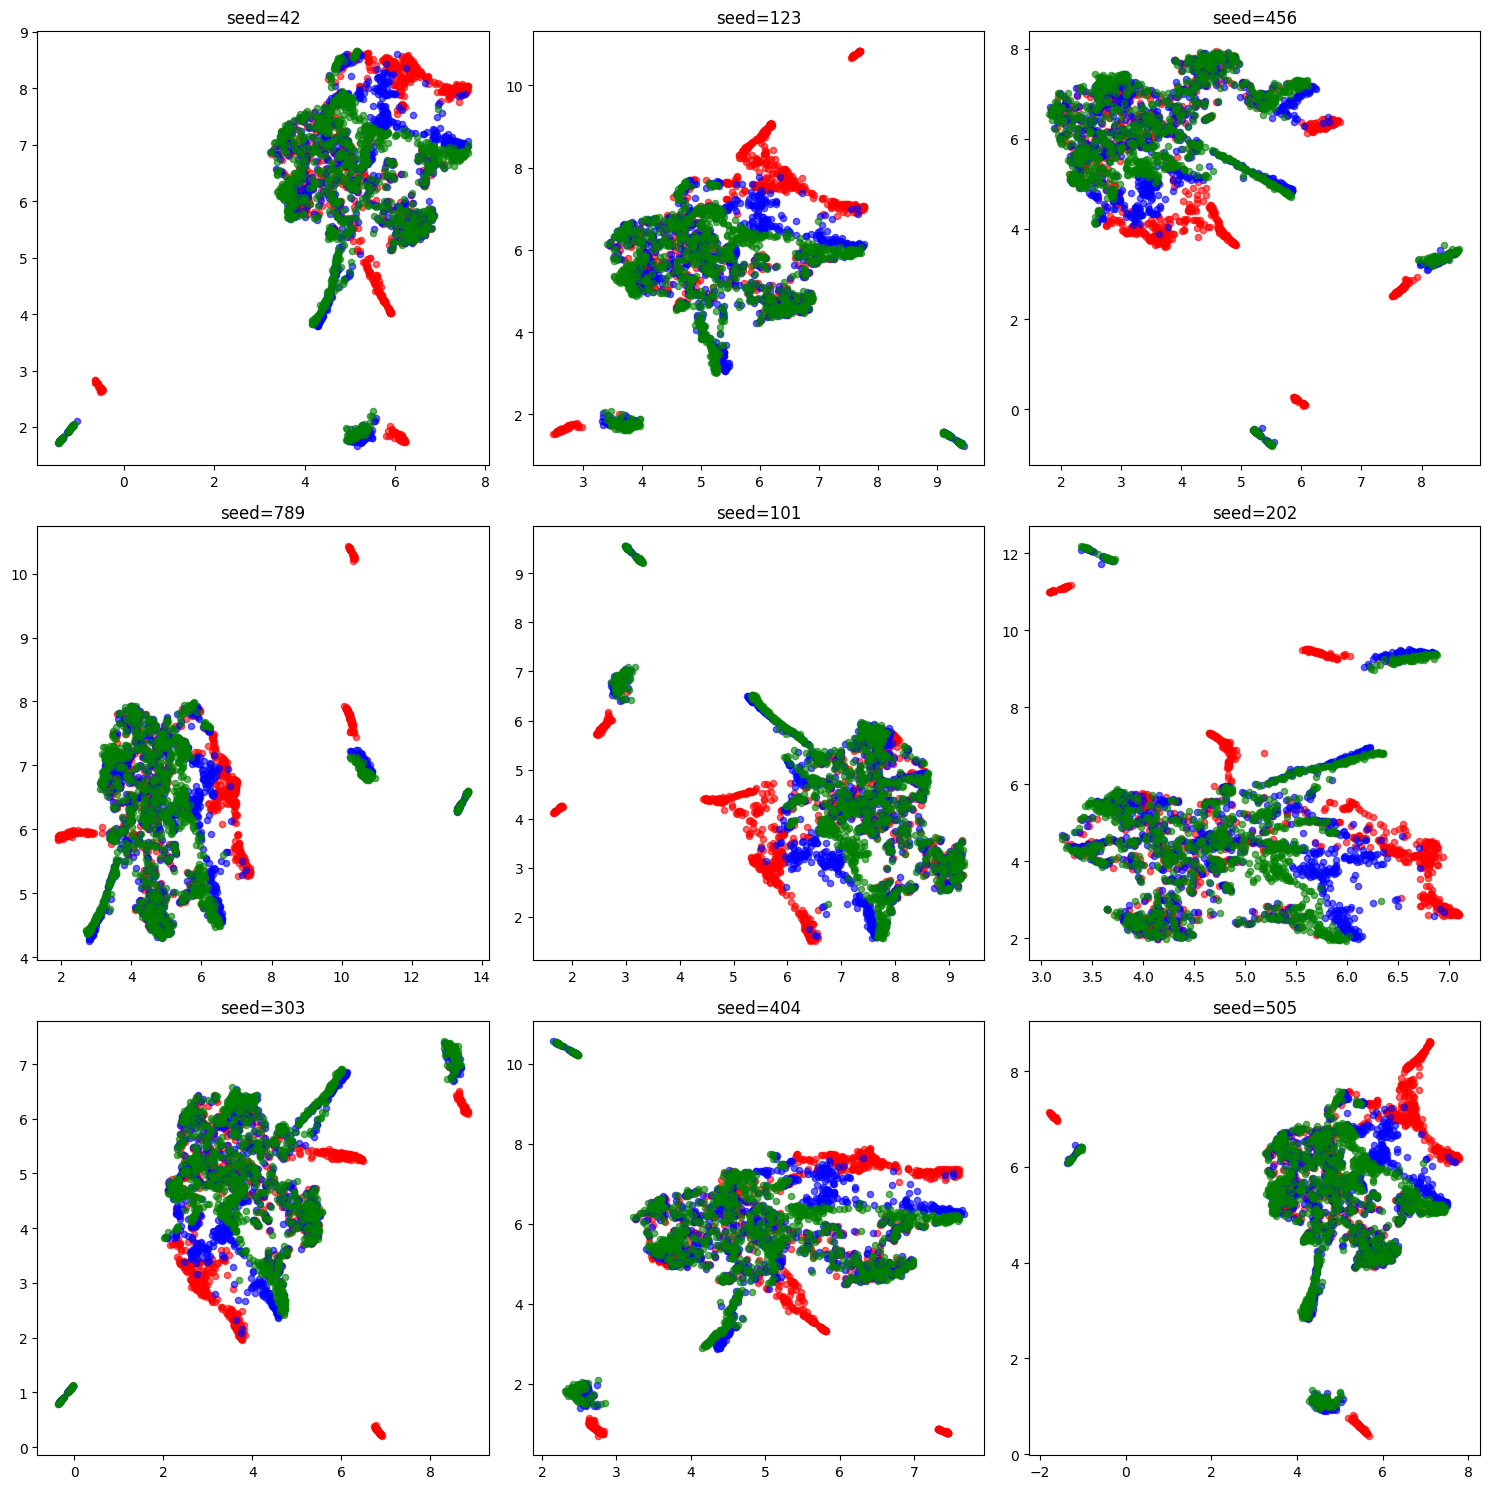

In [31]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
seeds = [42, 123, 456, 789, 101, 202, 303, 404, 505]

for ax, seed in zip(axes.flat, seeds):
    reducer = umap.UMAP(
        n_components=2,
        random_state=seed,
        n_neighbors=30,
        min_dist=0.1,
        metric='cosine',
        spread=0.5,
        init='random'
    )
    all_2d = reducer.fit_transform(all_embs)

    embs_o_o_2d = all_2d[:len(embs_o_o)]
    embs_o_h_2d = all_2d[len(embs_o_o):len(embs_o_o) + len(embs_o_h)]
    embs_h_h_2d = all_2d[len(embs_o_o) + len(embs_o_h):]

    ax.scatter(embs_o_o_2d[:, 0], embs_o_o_2d[:, 1], alpha=0.6, s=20, c='red')
    ax.scatter(embs_o_h_2d[:, 0], embs_o_h_2d[:, 1], alpha=0.6, s=20, c='blue')
    ax.scatter(embs_h_h_2d[:, 0], embs_h_h_2d[:, 1], alpha=0.6, s=20, c='green')
    ax.set_title(f'seed={seed}')

plt.tight_layout()
plt.show()


## Persist embeddings

In [34]:
# store embeddings here, then restart kernel to clear GPU for T5Gemma
%store all_embs all_2d

Stored 'all_embs' (ndarray)
Stored 'all_2d' (ndarray)


# Section 2: T5Gemma 2 (Out-of-the-Box, ~786M IT)

Load the off-the-shelf instruction-tuned T5Gemma 2 checkpoint (`google/t5gemma-2-270m-270m`), extract three-condition document embeddings, and visualize in 2D + 3D.

Restart the kernel before running this section if Section 1 was just executed -- both models live on GPU and the larger Gemma checkpoint will OOM if Han2Han is still resident.


## Load model

In [35]:
import warnings
warnings.filterwarnings("ignore")

# Load T5Gemma 2 (out-of-the-box, instruction-tuned)
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

model_name = "google/t5gemma-2-270m-270m"

tokenizer_gemma = AutoTokenizer.from_pretrained(model_name)
model_gemma = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto",
)
model_gemma.eval()

print(f"Loaded {model_name}")
print(f"Model params: {sum(p.numel() for p in model_gemma.parameters()):,}")
print(f"Model on: {next(model_gemma.parameters()).device}")

2026-05-26 18:22:04,766 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/google/t5gemma-2-270m-270m/resolve/main/config.json "HTTP/1.1 200 OK"
2026-05-26 18:22:05,003 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/google/t5gemma-2-270m-270m/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-26 18:22:05,338 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/google/t5gemma-2-270m-270m/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
2026-05-26 18:22:05,562 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/google/t5gemma-2-270m-270m/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
2026-05-26 18:22:05,793 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/google/t5gemma-2-270m-270m/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
2026-05-26 18:22:08,306 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/google/t5gemma-2-270m-270m "HTTP/1.1 200 O

Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

2026-05-26 18:22:10,280 - INFO - httpx - HTTP Request: HEAD https://huggingface.co/google/t5gemma-2-270m-270m/resolve/main/generation_config.json "HTTP/1.1 200 OK"
Loaded google/t5gemma-2-270m-270m
Model params: 786,029,296
Model on: cuda:0


## Load data

In [36]:
import polars as pl
from han2han_tools import transcribe

df = pl.read_ipc('casasia_umap.arrow')

articles_list = []
years_list = []
for article, year in df.iter_rows():
    articles_list.append(article)
    years_list.append(year)

print(f"Loaded {len(articles_list)} documents")

Loaded 1124 documents


## Extract embeddings

### 1. Original

In [37]:
# extract Gemma embeddings for original (Hanja) documents
from tqdm.auto import tqdm

yr_to_embs_gemma_o = {}
batch_size = 1

for i in tqdm(range(0, len(articles_list), batch_size), desc="Gemma Original"):
    batch_articles = articles_list[i:i + batch_size]
    batch_years = years_list[i:i + batch_size]

    batch_texts = [" ".join(article) for article in batch_articles]
    inputs = tokenizer_gemma(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    )
    inputs['decoder_input_ids'] = model_gemma.prepare_decoder_input_ids_from_labels(
        inputs['input_ids'].clone()
    )

    with torch.no_grad():
        outputs = model_gemma(
            **inputs.to(model_gemma.device),
            output_hidden_states=True,
            use_cache=False,
        )
        hidden_states = outputs.decoder_hidden_states[-1]

        attention_mask = (
            inputs['decoder_input_ids'] != tokenizer_gemma.pad_token_id
        ).unsqueeze(-1).to(hidden_states.device)
        masked_hidden = hidden_states * attention_mask
        sum_hidden = masked_hidden.sum(dim=1)
        final_embeddings = sum_hidden / attention_mask.sum(dim=1)

    for year, embedding in zip(batch_years, final_embeddings.float().cpu().numpy()):
        yr_to_embs_gemma_o.setdefault(year, [])
        yr_to_embs_gemma_o[year].append(embedding)

print(f"Extracted {sum(len(v) for v in yr_to_embs_gemma_o.values())} embeddings")

Gemma Original:   0%|          | 0/1124 [00:00<?, ?it/s]

Extracted 1124 embeddings


### 2. Hangul

In [38]:
# extract Gemma embeddings for Hangul-transcribed documents
yr_to_embs_gemma_h = {}

for i in tqdm(range(0, len(articles_list), batch_size), desc="Gemma Hangul"):
    batch_articles = articles_list[i:i + batch_size]
    batch_years = years_list[i:i + batch_size]

    batch_texts = [transcribe(" ".join(article)) for article in batch_articles]
    inputs = tokenizer_gemma(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    ).to(model_gemma.device)

    inputs['decoder_input_ids'] = model_gemma.prepare_decoder_input_ids_from_labels(
        inputs['input_ids'].clone()
    )

    with torch.no_grad():
        outputs = model_gemma(
            **inputs.to(model_gemma.device),
            output_hidden_states=True,
            use_cache=False,
        )
        hidden_states = outputs.decoder_hidden_states[-1]

        attention_mask = (
            inputs['decoder_input_ids'] != tokenizer_gemma.pad_token_id
        ).unsqueeze(-1).to(hidden_states.device)
        masked_hidden = hidden_states * attention_mask
        sum_hidden = masked_hidden.sum(dim=1)
        final_embeddings = sum_hidden / attention_mask.sum(dim=1)

    for year, embedding in zip(batch_years, final_embeddings.float().cpu().numpy()):
        yr_to_embs_gemma_h.setdefault(year, [])
        yr_to_embs_gemma_h[year].append(embedding)

print(f"Extracted {sum(len(v) for v in yr_to_embs_gemma_h.values())} embeddings")

Gemma Hangul:   0%|          | 0/1124 [00:00<?, ?it/s]

Extracted 1124 embeddings


### 3. Original -> Hangul (cross-attention)

In [39]:
# Hanja encoder input, Hangul decoder input -- exercises cross-attention
yr_to_embs_gemma_o_h = {}

for i in tqdm(range(0, len(articles_list), batch_size), desc="Gemma Orig->Hangul"):
    batch_articles = articles_list[i:i + batch_size]
    batch_years = years_list[i:i + batch_size]

    batch_texts = [" ".join(article) for article in batch_articles]
    hangul_texts = [transcribe(text) for text in batch_texts]

    inputs = tokenizer_gemma(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    )
    decoder_inputs = tokenizer_gemma(
        hangul_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    )
    inputs['decoder_input_ids'] = model_gemma.prepare_decoder_input_ids_from_labels(
        decoder_inputs['input_ids']
    )
    inputs['decoder_attention_mask'] = (
        inputs['decoder_input_ids'] != tokenizer_gemma.pad_token_id
    )

    with torch.no_grad():
        outputs = model_gemma(
            **inputs.to(model_gemma.device),
            output_hidden_states=True,
            use_cache=False,
        )
        hidden_states = outputs.decoder_hidden_states[-1]

        attention_mask = inputs['decoder_attention_mask'].unsqueeze(-1).to(hidden_states.device)
        masked_hidden = hidden_states * attention_mask
        sum_hidden = masked_hidden.sum(dim=1)
        final_embeddings = sum_hidden / attention_mask.sum(dim=1)

    for year, embedding in zip(batch_years, final_embeddings.float().cpu().numpy()):
        yr_to_embs_gemma_o_h.setdefault(year, [])
        yr_to_embs_gemma_o_h[year].append(embedding)

print(f"Extracted {sum(len(v) for v in yr_to_embs_gemma_o_h.values())} embeddings")

Gemma Orig->Hangul:   0%|          | 0/1124 [00:00<?, ?it/s]

Extracted 1124 embeddings


## UMAP visualization

In [40]:
from itertools import chain
import numpy as np
import umap
import matplotlib.pyplot as plt

embs_gemma_o = np.vstack([*chain.from_iterable(yr_to_embs_gemma_o.values())])
embs_gemma_h = np.vstack([*chain.from_iterable(yr_to_embs_gemma_h.values())])
embs_gemma_o_h = np.vstack([*chain.from_iterable(yr_to_embs_gemma_o_h.values())])

print(f"Original: {embs_gemma_o.shape}")
print(f"Hangul:   {embs_gemma_h.shape}")
print(f"Orig->H:  {embs_gemma_o_h.shape}")

all_gemma_embs = np.vstack([embs_gemma_o, embs_gemma_h, embs_gemma_o_h])

Original: (1124, 640)
Hangul:   (1124, 640)
Orig->H:  (1124, 640)


### 2D

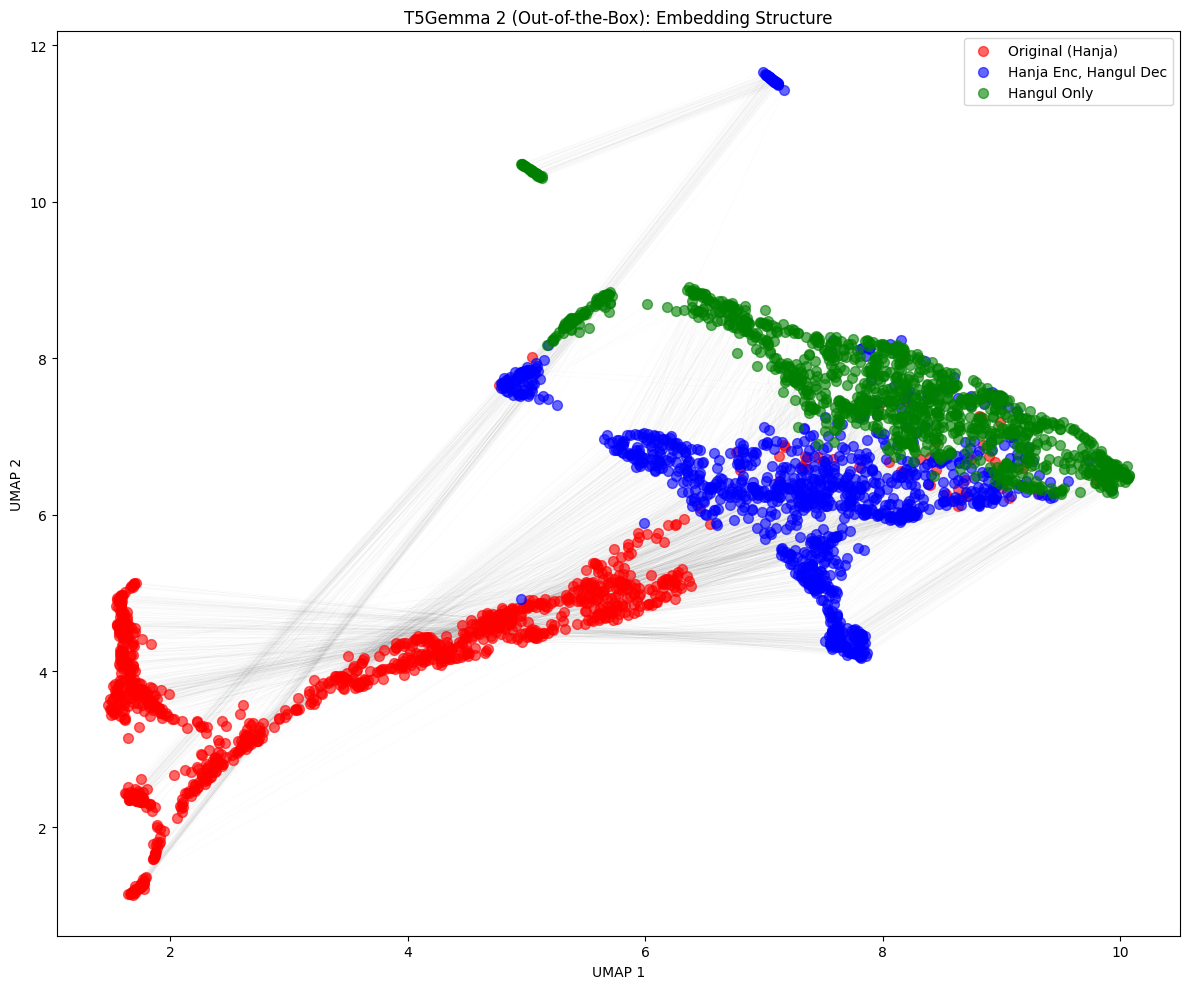

In [41]:
reducer = umap.UMAP(
    n_components=2,
    random_state=202,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    spread=0.5,
    init='random',
)
all_gemma_2d = reducer.fit_transform(all_gemma_embs)

n = len(embs_gemma_o)
embs_gemma_o_2d = all_gemma_2d[:n]
embs_gemma_h_2d = all_gemma_2d[n:2 * n]
embs_gemma_o_h_2d = all_gemma_2d[2 * n:]

plt.figure(figsize=(12, 10))
for i in range(n):
    pts = np.array([embs_gemma_o_2d[i], embs_gemma_o_h_2d[i], embs_gemma_h_2d[i]])
    plt.plot(pts[:, 0], pts[:, 1], 'k-', alpha=0.02, linewidth=0.5, zorder=1)

plt.scatter(embs_gemma_o_2d[:, 0], embs_gemma_o_2d[:, 1],
            label='Original (Hanja)', alpha=0.6, s=50, c='red', zorder=2)
plt.scatter(embs_gemma_o_h_2d[:, 0], embs_gemma_o_h_2d[:, 1],
            label='Hanja Enc, Hangul Dec', alpha=0.6, s=50, c='blue', zorder=2)
plt.scatter(embs_gemma_h_2d[:, 0], embs_gemma_h_2d[:, 1],
            label='Hangul Only', alpha=0.6, s=50, c='green', zorder=2)

plt.title('T5Gemma 2 (Out-of-the-Box): Embedding Structure')
plt.legend()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

### 3D

In [42]:
import plotly.graph_objects as go

reducer_3d = umap.UMAP(
    n_components=3,
    random_state=202,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    spread=0.5,
    init='random',
)
all_gemma_3d = reducer_3d.fit_transform(all_gemma_embs)

embs_gemma_o_3d = all_gemma_3d[:n]
embs_gemma_h_3d = all_gemma_3d[n:2 * n]
embs_gemma_o_h_3d = all_gemma_3d[2 * n:]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=embs_gemma_o_3d[:, 0], y=embs_gemma_o_3d[:, 1], z=embs_gemma_o_3d[:, 2],
    mode='markers', marker=dict(size=4, color='red', opacity=0.6),
    name='Original (Hanja)',
))
fig.add_trace(go.Scatter3d(
    x=embs_gemma_o_h_3d[:, 0], y=embs_gemma_o_h_3d[:, 1], z=embs_gemma_o_h_3d[:, 2],
    mode='markers', marker=dict(size=4, color='blue', opacity=0.6),
    name='Hanja Enc, Hangul Dec',
))
fig.add_trace(go.Scatter3d(
    x=embs_gemma_h_3d[:, 0], y=embs_gemma_h_3d[:, 1], z=embs_gemma_h_3d[:, 2],
    mode='markers', marker=dict(size=4, color='green', opacity=0.6),
    name='Hangul Only',
))

for i in range(n):
    fig.add_trace(go.Scatter3d(
        x=[embs_gemma_o_3d[i, 0], embs_gemma_o_h_3d[i, 0], embs_gemma_h_3d[i, 0]],
        y=[embs_gemma_o_3d[i, 1], embs_gemma_o_h_3d[i, 1], embs_gemma_h_3d[i, 1]],
        z=[embs_gemma_o_3d[i, 2], embs_gemma_o_h_3d[i, 2], embs_gemma_h_3d[i, 2]],
        mode='lines', line=dict(color='gray', width=1), opacity=0.1,
        showlegend=False,
    ))

fig.update_layout(
    title='T5Gemma 2 (Out-of-the-Box): Embedding Structure (3D)',
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='white',
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    width=900, height=700,
)
fig.show()

## Persist embeddings

In [43]:
%store embs_gemma_o embs_gemma_h embs_gemma_o_h all_gemma_embs all_gemma_2d embs_gemma_o_2d embs_gemma_h_2d embs_gemma_o_h_2d

Stored 'embs_gemma_o' (ndarray)
Stored 'embs_gemma_h' (ndarray)
Stored 'embs_gemma_o_h' (ndarray)
Stored 'all_gemma_embs' (ndarray)
Stored 'all_gemma_2d' (ndarray)
Stored 'embs_gemma_o_2d' (ndarray)
Stored 'embs_gemma_h_2d' (ndarray)
Stored 'embs_gemma_o_h_2d' (ndarray)


# Section 3: T5Gemma 2 (Fine-Tuned, ~786M FT)

Load the fine-tuned T5Gemma 2 checkpoint (`t5gemma2_all`, trained with the Han2Han denoising recipe), extract three-condition document embeddings, and visualize in 2D + 3D.

Restart the kernel before running if Section 2 was just executed. The setup cell below also frees any T5Gemma 2 IT model state still resident in GPU memory.

## Free GPU + load model

In [44]:
import warnings
warnings.filterwarnings("ignore")

import gc

try:
    del model_gemma
    del tokenizer_gemma
except NameError:
    pass
gc.collect()

import torch
if torch.cuda.is_available():
    torch.cuda.empty_cache()

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "t5gemma2_all"  # local fine-tuned checkpoint (Han2Han recipe)

tokenizer_gemma = AutoTokenizer.from_pretrained(model_name)
model_gemma = AutoModelForSeq2SeqLM.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device_map="auto",
)
model_gemma.eval()

print(f"Loaded {model_name}")
print(f"Model params: {sum(p.numel() for p in model_gemma.parameters()):,}")
print(f"Model on: {next(model_gemma.parameters()).device}")

Loading weights:   0%|          | 0/911 [00:00<?, ?it/s]

Loaded t5gemma2_all
Model params: 786,029,296
Model on: cuda:0


## Load data

In [45]:
import polars as pl
from han2han_tools import transcribe

df = pl.read_ipc('casasia_umap.arrow')

articles_list = []
years_list = []
for article, year in df.iter_rows():
    articles_list.append(article)
    years_list.append(year)

print(f"Loaded {len(articles_list)} documents")

Loaded 1124 documents


## Extract embeddings

### 1. Original

In [46]:
from tqdm.auto import tqdm

yr_to_embs_gemma_ft_o = {}
batch_size = 1

for i in tqdm(range(0, len(articles_list), batch_size), desc="Gemma-FT Original"):
    batch_articles = articles_list[i:i + batch_size]
    batch_years = years_list[i:i + batch_size]

    batch_texts = [" ".join(article) for article in batch_articles]
    inputs = tokenizer_gemma(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    )
    inputs['decoder_input_ids'] = model_gemma.prepare_decoder_input_ids_from_labels(
        inputs['input_ids'].clone()
    )

    with torch.no_grad():
        outputs = model_gemma(
            **inputs.to(model_gemma.device),
            output_hidden_states=True,
            use_cache=False,
        )
        hidden_states = outputs.decoder_hidden_states[-1]

        attention_mask = (
            inputs['decoder_input_ids'] != tokenizer_gemma.pad_token_id
        ).unsqueeze(-1).to(hidden_states.device)
        masked_hidden = hidden_states * attention_mask
        sum_hidden = masked_hidden.sum(dim=1)
        final_embeddings = sum_hidden / attention_mask.sum(dim=1)

    for year, embedding in zip(batch_years, final_embeddings.float().cpu().numpy()):
        yr_to_embs_gemma_ft_o.setdefault(year, [])
        yr_to_embs_gemma_ft_o[year].append(embedding)

print(f"Extracted {sum(len(v) for v in yr_to_embs_gemma_ft_o.values())} embeddings")

Gemma-FT Original:   0%|          | 0/1124 [00:00<?, ?it/s]

Extracted 1124 embeddings


### 2. Hangul

In [47]:
yr_to_embs_gemma_ft_h = {}

for i in tqdm(range(0, len(articles_list), batch_size), desc="Gemma-FT Hangul"):
    batch_articles = articles_list[i:i + batch_size]
    batch_years = years_list[i:i + batch_size]

    batch_texts = [transcribe(" ".join(article)) for article in batch_articles]
    inputs = tokenizer_gemma(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    ).to(model_gemma.device)

    inputs['decoder_input_ids'] = model_gemma.prepare_decoder_input_ids_from_labels(
        inputs['input_ids'].clone()
    )

    with torch.no_grad():
        outputs = model_gemma(
            **inputs.to(model_gemma.device),
            output_hidden_states=True,
            use_cache=False,
        )
        hidden_states = outputs.decoder_hidden_states[-1]

        attention_mask = (
            inputs['decoder_input_ids'] != tokenizer_gemma.pad_token_id
        ).unsqueeze(-1).to(hidden_states.device)
        masked_hidden = hidden_states * attention_mask
        sum_hidden = masked_hidden.sum(dim=1)
        final_embeddings = sum_hidden / attention_mask.sum(dim=1)

    for year, embedding in zip(batch_years, final_embeddings.float().cpu().numpy()):
        yr_to_embs_gemma_ft_h.setdefault(year, [])
        yr_to_embs_gemma_ft_h[year].append(embedding)

print(f"Extracted {sum(len(v) for v in yr_to_embs_gemma_ft_h.values())} embeddings")

Gemma-FT Hangul:   0%|          | 0/1124 [00:00<?, ?it/s]

Extracted 1124 embeddings


### 3. Original -> Hangul (cross-attention)

In [48]:
yr_to_embs_gemma_ft_o_h = {}

for i in tqdm(range(0, len(articles_list), batch_size), desc="Gemma-FT Orig->Hangul"):
    batch_articles = articles_list[i:i + batch_size]
    batch_years = years_list[i:i + batch_size]

    batch_texts = [" ".join(article) for article in batch_articles]
    hangul_texts = [transcribe(text) for text in batch_texts]

    inputs = tokenizer_gemma(
        batch_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    )
    decoder_inputs = tokenizer_gemma(
        hangul_texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=512,
    )
    inputs['decoder_input_ids'] = model_gemma.prepare_decoder_input_ids_from_labels(
        decoder_inputs['input_ids']
    )
    inputs['decoder_attention_mask'] = (
        inputs['decoder_input_ids'] != tokenizer_gemma.pad_token_id
    )

    with torch.no_grad():
        outputs = model_gemma(
            **inputs.to(model_gemma.device),
            output_hidden_states=True,
            use_cache=False,
        )
        hidden_states = outputs.decoder_hidden_states[-1]

        attention_mask = inputs['decoder_attention_mask'].unsqueeze(-1).to(hidden_states.device)
        masked_hidden = hidden_states * attention_mask
        sum_hidden = masked_hidden.sum(dim=1)
        final_embeddings = sum_hidden / attention_mask.sum(dim=1)

    for year, embedding in zip(batch_years, final_embeddings.float().cpu().numpy()):
        yr_to_embs_gemma_ft_o_h.setdefault(year, [])
        yr_to_embs_gemma_ft_o_h[year].append(embedding)

print(f"Extracted {sum(len(v) for v in yr_to_embs_gemma_ft_o_h.values())} embeddings")

Gemma-FT Orig->Hangul:   0%|          | 0/1124 [00:00<?, ?it/s]

Extracted 1124 embeddings


## UMAP visualization

In [49]:
from itertools import chain
import numpy as np
import umap
import matplotlib.pyplot as plt

embs_gemma_ft_o = np.vstack([*chain.from_iterable(yr_to_embs_gemma_ft_o.values())])
embs_gemma_ft_h = np.vstack([*chain.from_iterable(yr_to_embs_gemma_ft_h.values())])
embs_gemma_ft_o_h = np.vstack([*chain.from_iterable(yr_to_embs_gemma_ft_o_h.values())])

print(f"Original: {embs_gemma_ft_o.shape}")
print(f"Hangul:   {embs_gemma_ft_h.shape}")
print(f"Orig->H:  {embs_gemma_ft_o_h.shape}")

all_gemma_ft_embs = np.vstack([embs_gemma_ft_o, embs_gemma_ft_h, embs_gemma_ft_o_h])

Original: (1124, 640)
Hangul:   (1124, 640)
Orig->H:  (1124, 640)


### 2D

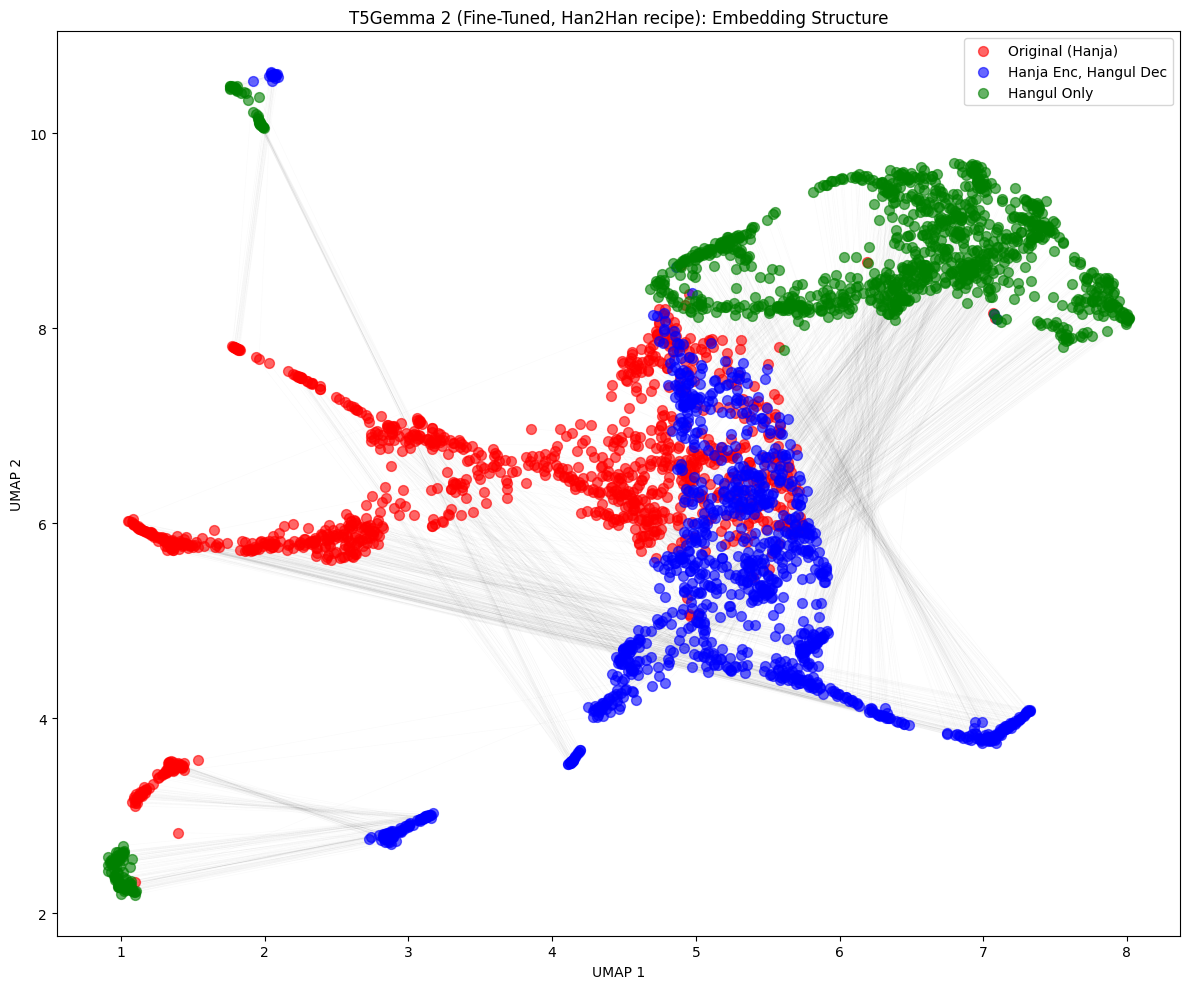

In [50]:
reducer = umap.UMAP(
    n_components=2,
    random_state=202,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    spread=0.5,
    init='random',
)
all_gemma_ft_2d = reducer.fit_transform(all_gemma_ft_embs)

n = len(embs_gemma_ft_o)
embs_gemma_ft_o_2d = all_gemma_ft_2d[:n]
embs_gemma_ft_h_2d = all_gemma_ft_2d[n:2 * n]
embs_gemma_ft_o_h_2d = all_gemma_ft_2d[2 * n:]

plt.figure(figsize=(12, 10))
for i in range(n):
    pts = np.array([embs_gemma_ft_o_2d[i], embs_gemma_ft_o_h_2d[i], embs_gemma_ft_h_2d[i]])
    plt.plot(pts[:, 0], pts[:, 1], 'k-', alpha=0.02, linewidth=0.5, zorder=1)

plt.scatter(embs_gemma_ft_o_2d[:, 0], embs_gemma_ft_o_2d[:, 1],
            label='Original (Hanja)', alpha=0.6, s=50, c='red', zorder=2)
plt.scatter(embs_gemma_ft_o_h_2d[:, 0], embs_gemma_ft_o_h_2d[:, 1],
            label='Hanja Enc, Hangul Dec', alpha=0.6, s=50, c='blue', zorder=2)
plt.scatter(embs_gemma_ft_h_2d[:, 0], embs_gemma_ft_h_2d[:, 1],
            label='Hangul Only', alpha=0.6, s=50, c='green', zorder=2)

plt.title('T5Gemma 2 (Fine-Tuned, Han2Han recipe): Embedding Structure')
plt.legend()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

### 3D

In [51]:
import plotly.graph_objects as go

reducer_3d = umap.UMAP(
    n_components=3,
    random_state=202,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    spread=0.5,
    init='random',
)
all_gemma_ft_3d = reducer_3d.fit_transform(all_gemma_ft_embs)

embs_gemma_ft_o_3d = all_gemma_ft_3d[:n]
embs_gemma_ft_h_3d = all_gemma_ft_3d[n:2 * n]
embs_gemma_ft_o_h_3d = all_gemma_ft_3d[2 * n:]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=embs_gemma_ft_o_3d[:, 0], y=embs_gemma_ft_o_3d[:, 1], z=embs_gemma_ft_o_3d[:, 2],
    mode='markers', marker=dict(size=4, color='red', opacity=0.6),
    name='Original (Hanja)',
))
fig.add_trace(go.Scatter3d(
    x=embs_gemma_ft_o_h_3d[:, 0], y=embs_gemma_ft_o_h_3d[:, 1], z=embs_gemma_ft_o_h_3d[:, 2],
    mode='markers', marker=dict(size=4, color='blue', opacity=0.6),
    name='Hanja Enc, Hangul Dec',
))
fig.add_trace(go.Scatter3d(
    x=embs_gemma_ft_h_3d[:, 0], y=embs_gemma_ft_h_3d[:, 1], z=embs_gemma_ft_h_3d[:, 2],
    mode='markers', marker=dict(size=4, color='green', opacity=0.6),
    name='Hangul Only',
))

for i in range(n):
    fig.add_trace(go.Scatter3d(
        x=[embs_gemma_ft_o_3d[i, 0], embs_gemma_ft_o_h_3d[i, 0], embs_gemma_ft_h_3d[i, 0]],
        y=[embs_gemma_ft_o_3d[i, 1], embs_gemma_ft_o_h_3d[i, 1], embs_gemma_ft_h_3d[i, 1]],
        z=[embs_gemma_ft_o_3d[i, 2], embs_gemma_ft_o_h_3d[i, 2], embs_gemma_ft_h_3d[i, 2]],
        mode='lines', line=dict(color='gray', width=1), opacity=0.1,
        showlegend=False,
    ))

fig.update_layout(
    title='T5Gemma 2 (Fine-Tuned, Han2Han recipe): Embedding Structure (3D)',
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        bgcolor='white',
    ),
    paper_bgcolor='white',
    plot_bgcolor='white',
    width=900, height=700,
)
fig.show()

## Persist embeddings

In [52]:
%store embs_gemma_ft_o embs_gemma_ft_h embs_gemma_ft_o_h all_gemma_ft_embs all_gemma_ft_2d embs_gemma_ft_o_2d embs_gemma_ft_h_2d embs_gemma_ft_o_h_2d

Stored 'embs_gemma_ft_o' (ndarray)
Stored 'embs_gemma_ft_h' (ndarray)
Stored 'embs_gemma_ft_o_h' (ndarray)
Stored 'all_gemma_ft_embs' (ndarray)
Stored 'all_gemma_ft_2d' (ndarray)
Stored 'embs_gemma_ft_o_2d' (ndarray)
Stored 'embs_gemma_ft_h_2d' (ndarray)
Stored 'embs_gemma_ft_o_h_2d' (ndarray)


# Section 4: Paper Visualizations

Side-by-side comparisons used in the paper. Restore the stored 2D coordinates from Sections 1-3 and render Han2Han alongside each T5Gemma 2 variant.

## Restore stored embeddings

In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

%store -r all_2d
%store -r all_gemma_2d embs_gemma_o_2d embs_gemma_h_2d embs_gemma_o_h_2d
%store -r all_gemma_ft_2d embs_gemma_ft_o_2d embs_gemma_ft_h_2d embs_gemma_ft_o_h_2d

n_docs = 1124
embs_o_o_2d = all_2d[:n_docs]
embs_o_h_2d = all_2d[n_docs:2 * n_docs]
embs_h_h_2d = all_2d[2 * n_docs:]

# unified color scheme (matches LaTeX figures)
COLOR_HANJA = '#E2851D'      # orange - Hanja/original
COLOR_CROSSATTN = '#4682B4'  # steel blue - cross-attention condition
COLOR_HANGUL = '#58994C'     # green - Hangul

print(f"Han2Han 2D shape:  {all_2d.shape}")
print(f"T5G2-IT 2D shape:  {all_gemma_2d.shape}")
print(f"T5G2-FT 2D shape:  {all_gemma_ft_2d.shape}")

Han2Han 2D shape:  (3372, 2)
T5G2-IT 2D shape:  (3372, 2)
T5G2-FT 2D shape:  (3372, 2)


## Han2Han vs T5Gemma 2 (Out-of-the-Box)

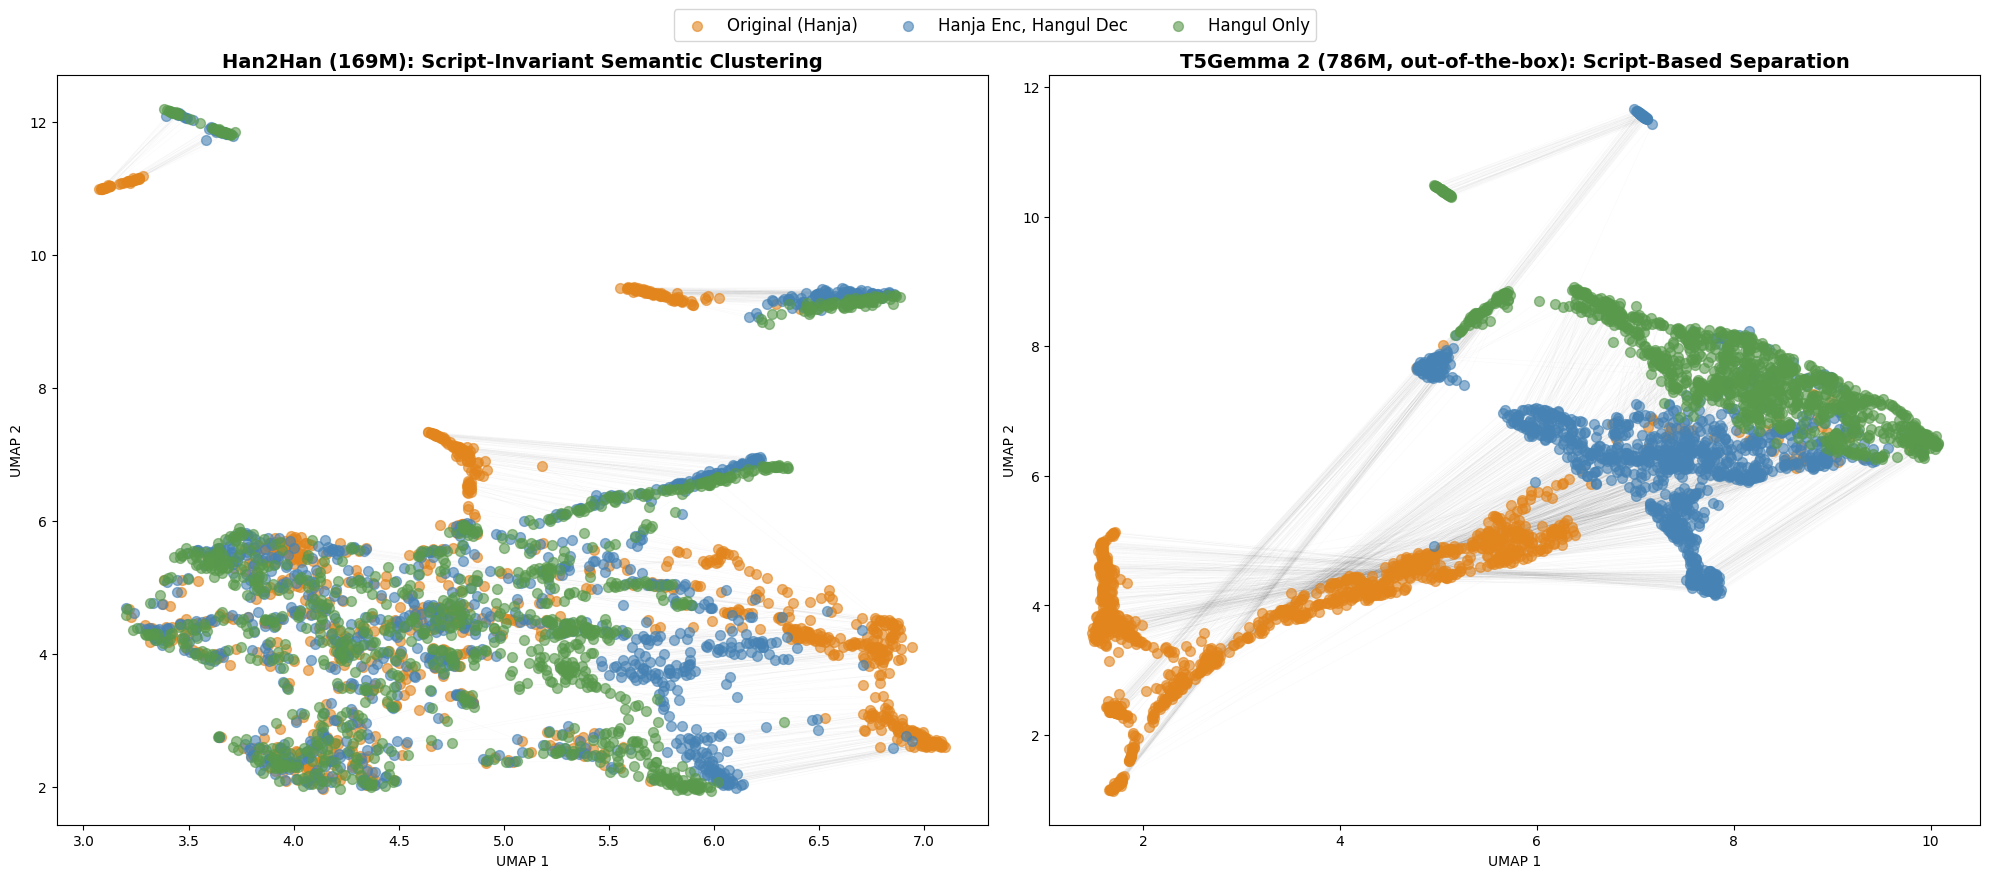

In [54]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

for i in range(n_docs):
    pts = np.array([embs_o_o_2d[i], embs_o_h_2d[i], embs_h_h_2d[i]])
    ax1.plot(pts[:, 0], pts[:, 1], 'k-', alpha=0.02, linewidth=0.5, zorder=1)

ax1.scatter(embs_o_o_2d[:, 0], embs_o_o_2d[:, 1],
            label='Original (Hanja)', alpha=0.6, s=50, c=COLOR_HANJA, zorder=2)
ax1.scatter(embs_o_h_2d[:, 0], embs_o_h_2d[:, 1],
            label='Hanja Enc, Hangul Dec', alpha=0.6, s=50, c=COLOR_CROSSATTN, zorder=2)
ax1.scatter(embs_h_h_2d[:, 0], embs_h_h_2d[:, 1],
            label='Hangul Only', alpha=0.6, s=50, c=COLOR_HANGUL, zorder=2)
ax1.set_title('Han2Han (169M): Script-Invariant Semantic Clustering',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')

for i in range(n_docs):
    pts = np.array([embs_gemma_o_2d[i], embs_gemma_o_h_2d[i], embs_gemma_h_2d[i]])
    ax2.plot(pts[:, 0], pts[:, 1], 'k-', alpha=0.02, linewidth=0.5, zorder=1)

ax2.scatter(embs_gemma_o_2d[:, 0], embs_gemma_o_2d[:, 1],
            label='Original (Hanja)', alpha=0.6, s=50, c=COLOR_HANJA, zorder=2)
ax2.scatter(embs_gemma_o_h_2d[:, 0], embs_gemma_o_h_2d[:, 1],
            label='Hanja Enc, Hangul Dec', alpha=0.6, s=50, c=COLOR_CROSSATTN, zorder=2)
ax2.scatter(embs_gemma_h_2d[:, 0], embs_gemma_h_2d[:, 1],
            label='Hangul Only', alpha=0.6, s=50, c=COLOR_HANGUL, zorder=2)
ax2.set_title('T5Gemma 2 (786M, out-of-the-box): Script-Based Separation',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 0.98), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('paper/han2han_vs_t5gemma2-IT_umap.png', dpi=300, bbox_inches='tight')
plt.show()

## Han2Han vs T5Gemma 2 (Fine-Tuned)

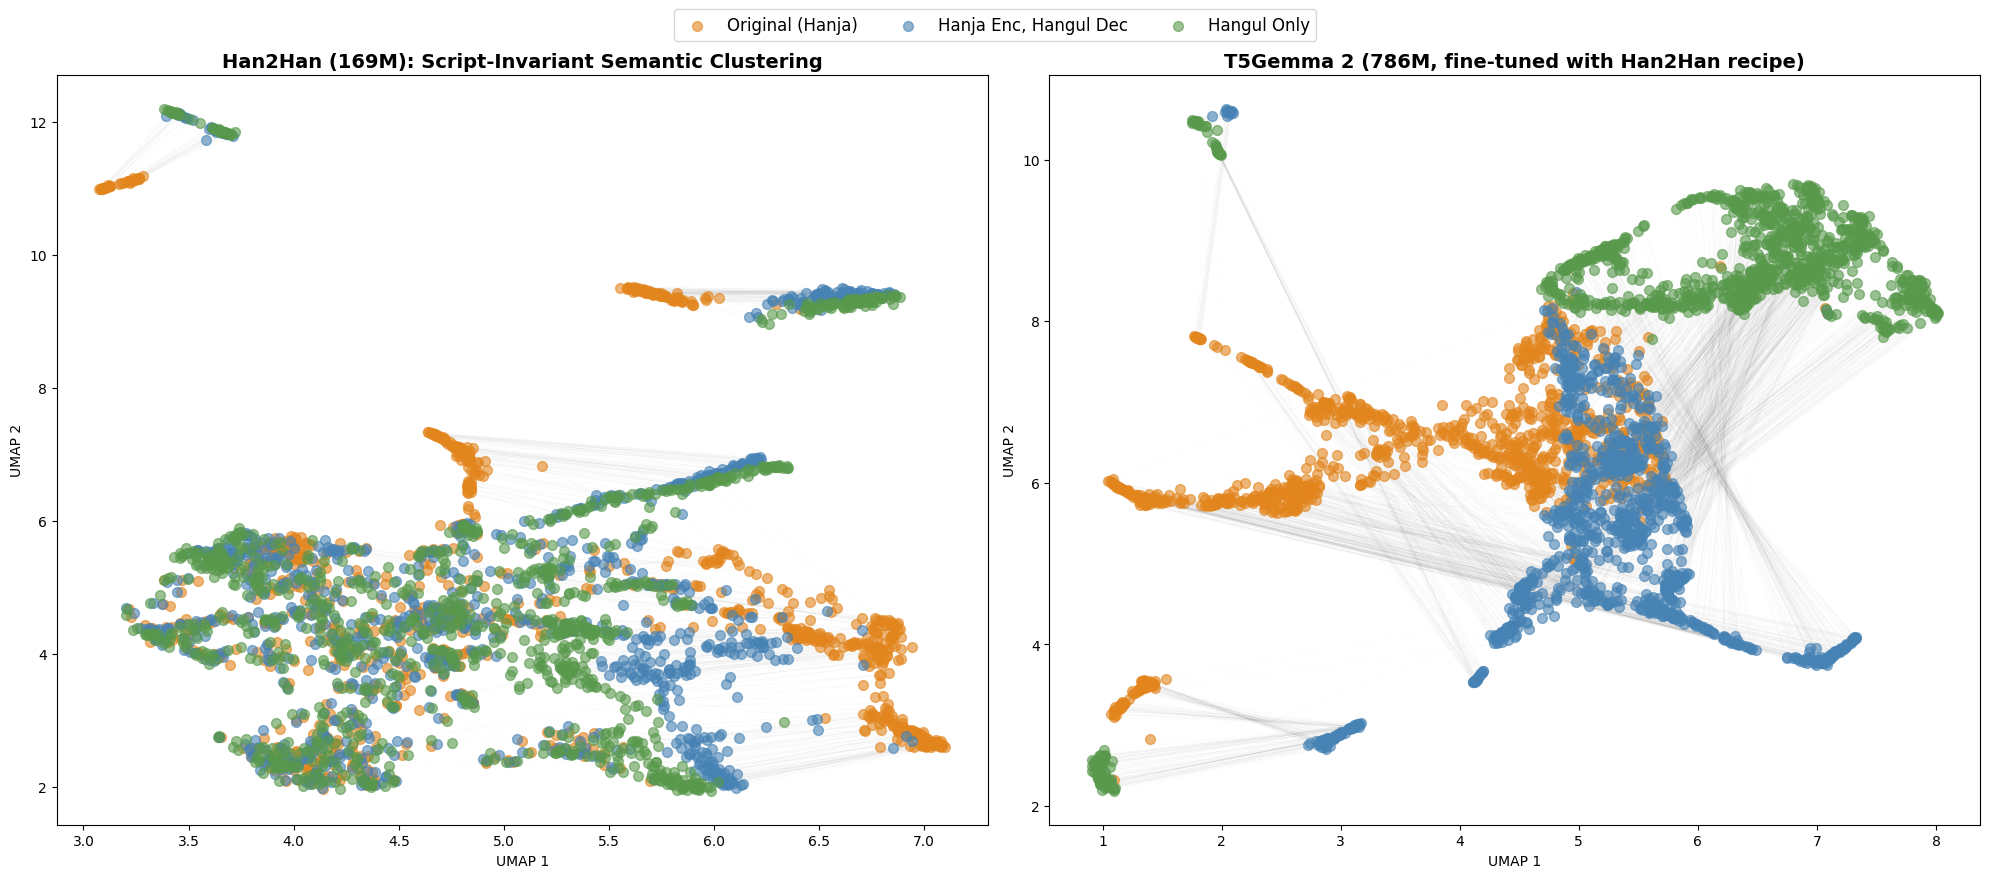

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

for i in range(n_docs):
    pts = np.array([embs_o_o_2d[i], embs_o_h_2d[i], embs_h_h_2d[i]])
    ax1.plot(pts[:, 0], pts[:, 1], 'k-', alpha=0.02, linewidth=0.5, zorder=1)

ax1.scatter(embs_o_o_2d[:, 0], embs_o_o_2d[:, 1],
            label='Original (Hanja)', alpha=0.6, s=50, c=COLOR_HANJA, zorder=2)
ax1.scatter(embs_o_h_2d[:, 0], embs_o_h_2d[:, 1],
            label='Hanja Enc, Hangul Dec', alpha=0.6, s=50, c=COLOR_CROSSATTN, zorder=2)
ax1.scatter(embs_h_h_2d[:, 0], embs_h_h_2d[:, 1],
            label='Hangul Only', alpha=0.6, s=50, c=COLOR_HANGUL, zorder=2)
ax1.set_title('Han2Han (169M): Script-Invariant Semantic Clustering',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')

for i in range(n_docs):
    pts = np.array([embs_gemma_ft_o_2d[i], embs_gemma_ft_o_h_2d[i], embs_gemma_ft_h_2d[i]])
    ax2.plot(pts[:, 0], pts[:, 1], 'k-', alpha=0.02, linewidth=0.5, zorder=1)

ax2.scatter(embs_gemma_ft_o_2d[:, 0], embs_gemma_ft_o_2d[:, 1],
            label='Original (Hanja)', alpha=0.6, s=50, c=COLOR_HANJA, zorder=2)
ax2.scatter(embs_gemma_ft_o_h_2d[:, 0], embs_gemma_ft_o_h_2d[:, 1],
            label='Hanja Enc, Hangul Dec', alpha=0.6, s=50, c=COLOR_CROSSATTN, zorder=2)
ax2.scatter(embs_gemma_ft_h_2d[:, 0], embs_gemma_ft_h_2d[:, 1],
            label='Hangul Only', alpha=0.6, s=50, c=COLOR_HANGUL, zorder=2)
ax2.set_title('T5Gemma 2 (786M, fine-tuned with Han2Han recipe)',
              fontsize=14, fontweight='bold')
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')

handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3,
           bbox_to_anchor=(0.5, 0.98), fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig('paper/han2han_vs_t5gemma2-FT_umap.png', dpi=300, bbox_inches='tight')
plt.show()

# Section 5: Quantitative Script-Invariance Metrics

Three metrics to quantify what Section 4's figures show qualitatively:

1. **Same-document cosine similarity**: cosine between Original and Hangul embeddings of the same document (higher = more script-invariant)
2. **Silhouette score on script labels**: how well-separated are script clusters? (lower = less separation = better)
3. **k-NN retrieval accuracy**: for each Original document, is its nearest Hangul neighbor the same document? (higher = better)

## Metrics implementation

In [56]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np


def compute_script_invariance_metrics(embs_original, embs_hangul, model_name="Model"):
    """Compute script-invariance metrics on document embeddings.

    Reports same-document cosine similarity (Original vs Hangul), silhouette
    score for script-based clustering (lower = better; representations cluster
    by content rather than script), and k-NN retrieval accuracy (each Hanja
    document's nearest Hangul neighbor should be its own transcription).

    Args:
        embs_original: (N, D) array of Original/Hanja document embeddings.
        embs_hangul:   (N, D) array of Hangul document embeddings.
        model_name:    label for display.

    Returns:
        dict of per-metric values.
    """
    n_docs = len(embs_original)
    assert len(embs_hangul) == n_docs, "Embedding counts must match"

    cos_per_doc = np.array([
        cosine_similarity(embs_original[i:i + 1], embs_hangul[i:i + 1])[0, 0]
        for i in range(n_docs)
    ])
    comb = np.vstack([embs_original, embs_hangul])
    labels = np.array([0] * n_docs + [1] * n_docs)
    sil = silhouette_score(comb, labels, metric='cosine')
    sim = cosine_similarity(embs_original, embs_hangul)
    knn_oh = (sim.argmax(axis=1) == np.arange(n_docs)).mean()
    knn_ho = (sim.argmax(axis=0) == np.arange(n_docs)).mean()

    results = {
        'same_doc_cosine_mean': float(cos_per_doc.mean()),
        'same_doc_cosine_std': float(cos_per_doc.std()),
        'silhouette_score': float(sil),
        'knn_retrieval_acc': float(knn_oh),
        'knn_retrieval_acc_reverse': float(knn_ho),
        'knn_retrieval_acc_bidi': float((knn_oh + knn_ho) / 2),
    }

    print(f"\n{'=' * 60}")
    print(f"Script-Invariance Metrics: {model_name}")
    print(f"{'=' * 60}")
    print(f"{'Same-doc cosine (mean)':<32} {results['same_doc_cosine_mean']:>10.4f}")
    print(f"{'Same-doc cosine (std)':<32} {results['same_doc_cosine_std']:>10.4f}")
    print(f"{'Silhouette (lower=better)':<32} {results['silhouette_score']:>10.4f}")
    print(f"{'k-NN bidi (higher=better)':<32} {results['knn_retrieval_acc_bidi']:>10.4f}")
    print(f"{'=' * 60}\n")

    return results


## Compute metrics across all three models

In [57]:
%store -r all_embs
%store -r embs_gemma_o embs_gemma_h embs_gemma_o_h
%store -r embs_gemma_ft_o embs_gemma_ft_h embs_gemma_ft_o_h

n_docs = 1124
embs_o_o = all_embs[:n_docs]
embs_o_h = all_embs[n_docs:2 * n_docs]
embs_h_h = all_embs[2 * n_docs:]

print(f"Han2Han: {embs_o_o.shape}")
print(f"T5Gemma 2 (IT): {embs_gemma_o.shape}")
print(f"T5Gemma 2 (FT): {embs_gemma_ft_o.shape}")

# Original vs Hangul (script-invariance proper)
h2h_results = compute_script_invariance_metrics(
    embs_o_o, embs_h_h, model_name="Han2Han (169M)"
)
gemma_results = compute_script_invariance_metrics(
    embs_gemma_o, embs_gemma_h, model_name="T5Gemma 2 (786M) out-of-the-box"
)
gemma_ft_results = compute_script_invariance_metrics(
    embs_gemma_ft_o, embs_gemma_ft_h, model_name="T5Gemma 2 (786M) fine-tuned"
)

# Original vs cross-attention condition (encoder filtering capacity)
h2h_cross = compute_script_invariance_metrics(
    embs_o_o, embs_o_h, model_name="Han2Han (169M) [Orig vs Cross-Attn]"
)
gemma_cross = compute_script_invariance_metrics(
    embs_gemma_o, embs_gemma_o_h, model_name="T5Gemma 2 (786M) OOB [Orig vs Cross-Attn]"
)
gemma_ft_cross = compute_script_invariance_metrics(
    embs_gemma_ft_o, embs_gemma_ft_o_h, model_name="T5Gemma 2 (786M) FT [Orig vs Cross-Attn]"
)

Han2Han: (1124, 640)
T5Gemma 2 (IT): (1124, 640)
T5Gemma 2 (FT): (1124, 640)

Script-Invariance Metrics: Han2Han (169M)
Same-doc cosine (mean)               0.8331
Same-doc cosine (std)                0.1368
Silhouette (lower=better)            0.2132
k-NN bidi (higher=better)            0.6223


Script-Invariance Metrics: T5Gemma 2 (786M) out-of-the-box
Same-doc cosine (mean)               0.8390
Same-doc cosine (std)                0.1174
Silhouette (lower=better)            0.5108
k-NN bidi (higher=better)            0.0254


Script-Invariance Metrics: T5Gemma 2 (786M) fine-tuned
Same-doc cosine (mean)               0.9720
Same-doc cosine (std)                0.0380
Silhouette (lower=better)            0.1149
k-NN bidi (higher=better)            0.5810


Script-Invariance Metrics: Han2Han (169M) [Orig vs Cross-Attn]
Same-doc cosine (mean)               0.9035
Same-doc cosine (std)                0.1109
Silhouette (lower=better)            0.1303
k-NN bidi (higher=better)            

## Summary tables

In [58]:
def _row(name, r, width=44):
    return (
        f"{name:<{width}} "
        f"{r['same_doc_cosine_mean']:>10.4f} "
        f"{r['silhouette_score']:>10.4f} "
        f"{r['knn_retrieval_acc_bidi']:>10.4f}"
    )


def _header(width=44):
    return (
        f"{'Model':<{width}} "
        f"{'Cosine':>10} "
        f"{'Silhouette':>10} "
        f"{'kNN-bidi':>10}"
    )


_w = 80
print("\n" + "=" * _w)
print("Script-Invariance Comparison (Original vs Hangul)")
print("=" * _w)
print(_header())
print("-" * _w)
print(_row("Han2Han (169M)", h2h_results))
print(_row("T5Gemma 2 (786M) pre-FT", gemma_results))
print(_row("T5Gemma 2 (786M) post-FT (Han2Han recipe)", gemma_ft_results))
print("=" * _w)

print("\n" + "=" * _w)
print("Script-Invariance Comparison (Original vs Cross-Attn)")
print("=" * _w)
print(_header())
print("-" * _w)
print(_row("Han2Han (169M)", h2h_cross))
print(_row("T5Gemma 2 (786M) pre-FT", gemma_cross))
print(_row("T5Gemma 2 (786M) post-FT (Han2Han recipe)", gemma_ft_cross))
print("=" * _w)


Script-Invariance Comparison (Original vs Hangul)
Model                                            Cosine Silhouette   kNN-bidi
--------------------------------------------------------------------------------
Han2Han (169M)                                   0.8331     0.2132     0.6223
T5Gemma 2 (786M) pre-FT                          0.8390     0.5108     0.0254
T5Gemma 2 (786M) post-FT (Han2Han recipe)        0.9720     0.1149     0.5810

Script-Invariance Comparison (Original vs Cross-Attn)
Model                                            Cosine Silhouette   kNN-bidi
--------------------------------------------------------------------------------
Han2Han (169M)                                   0.9035     0.1303     0.8060
T5Gemma 2 (786M) pre-FT                          0.8760     0.4462     0.0414
T5Gemma 2 (786M) post-FT (Han2Han recipe)        0.9559     0.2274     0.3910
